### Analytical Solution of the Difference Equation

**Difference Equation:** $y[n]=\frac{5}{6}y[n-1]-\frac{1}{6}y[n-2]+x[n]$

**Input:** $x[n]=2^n u[n]$

**Characteristic Polynomial:** $\lambda^2-\frac{5}{6}\lambda+\frac{1}{6}=0$

**Characteristic Roots:** $\lambda_1=1/3$, $\lambda_2=1/2$

...

### Symbolic Verification

Eq(y[n] - y_zi[n] - y_zs[n], 0)

Verification successful: y[n] = y_zi[n] + y_zs[n].


### Numerical Verification

Maximum deviation = 0.000e+00


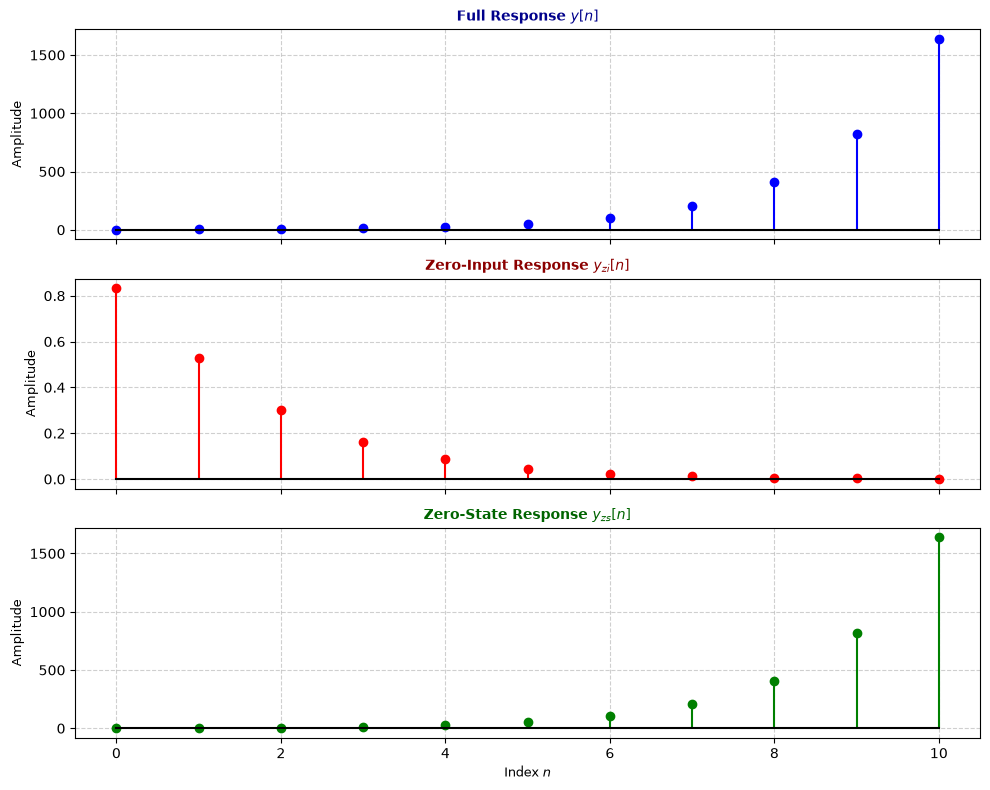

In [2]:
# ==========================================================
# Notebook: General Solution of a Second-Order Difference Equation
#
# System:
#
# y[n] = (5/6)y[n-1] - (1/6)y[n-2] + x[n]
#
# Input:
#
# x[n] = 2^n u[n]
#
# ==========================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ==========================================================
# Symbolic Variables
# ==========================================================

n = sp.symbols('n', integer=True)
ym1, ym2 = sp.symbols('y[-1] y[-2]', real=True)

u = sp.Heaviside

# ==========================================================
# 1. Homogeneous Equation and Characteristic Roots
# ==========================================================

lam = sp.symbols('lambda')
char_poly = lam**2 - sp.Rational(5, 6)*lam + sp.Rational(1, 6)
roots = sp.solve(char_poly, lam)

r1, r2 = roots

display(Markdown("### Analytical Solution of the Difference Equation"))
display(Markdown(r"**Difference Equation:** $y[n]=\frac{5}{6}y[n-1]-\frac{1}{6}y[n-2]+x[n]$"))
display(Markdown(r"**Input:** $x[n]=2^n u[n]$"))
display(Markdown(r"**Characteristic Polynomial:** $\lambda^2-\frac{5}{6}\lambda+\frac{1}{6}=0$"))
display(Markdown(f"**Characteristic Roots:** $\\lambda_1={r1}$, $\\lambda_2={r2}$"))

# ==========================================================
# 2. Particular Solution
# ==========================================================

k = sp.symbols('k')
yp = k * sp.Integer(2)**n

eq_k = sp.Eq(k*4 - sp.Rational(5, 6)*k*2 + sp.Rational(1, 6)*k, 4)
k_value = sp.solve(eq_k, k)[0]

display(Markdown(f"**Particular Solution:** $y_p[n]={sp.latex(k_value)}\\,2^n u[n]$"))

# ==========================================================
# 3. General Solution
# ==========================================================

C1, C2 = sp.symbols('C_1 C_2')

y_general = (k_value*sp.Integer(2)**n + C1*r1**n + C2*r2**n) * u(n)

# ==========================================================
# 4. Determine C1 and C2 from y[-1] and y[-2]
# ==========================================================

y0 = sp.Rational(5, 6)*ym1 - sp.Rational(1, 6)*ym2 + 1
y1 = sp.Rational(5, 6)*y0 - sp.Rational(1, 6)*ym1 + 2

eq_C1 = sp.Eq(C1 + C2, y0 - k_value)
eq_C2 = sp.Eq(C1*r1 + C2*r2, y1 - 2*k_value)

Csol = sp.solve((eq_C1, eq_C2), (C1, C2), simplify=True)

C1_sol = sp.simplify(Csol[C1])
C2_sol = sp.simplify(Csol[C2])

display(Markdown("### Constants from the Initial Conditions"))
display(sp.Eq(C1, C1_sol))
display(sp.Eq(C2, C2_sol))

# ==========================================================
# 5. Full Analytical Solution
# ==========================================================

y_full = sp.simplify(
    (k_value*sp.Integer(2)**n + C1_sol*r1**n + C2_sol*r2**n) * u(n)
)

display(Markdown("### General Solution of the Full Difference Equation"))
display(sp.Eq(sp.Symbol('y[n]'), y_full))

# ==========================================================
# 6. Zero-Input Response
# ==========================================================

y_zi = sp.simplify(
    (sp.Rational(3, 2)*ym1 - sp.Rational(1, 2)*ym2) * sp.Rational(1, 2)**n * u(n)
    + (-sp.Rational(2, 3)*ym1 + sp.Rational(1, 3)*ym2) * sp.Rational(1, 3)**n * u(n)
)

display(Markdown("### Zero-Input Response"))
display(sp.Eq(sp.Symbol('y_zi[n]'), y_zi))

# ==========================================================
# 7. Impulse Response
# ==========================================================

h = (3*sp.Rational(1, 2)**n - 2*sp.Rational(1, 3)**n) * u(n)

display(Markdown("### Impulse Response"))
display(sp.Eq(sp.Symbol('h[n]'), h))

# ==========================================================
# 8. Zero-State Response
# ==========================================================

y_zs = (
    sp.Rational(8, 5)*sp.Integer(2)**n
    - sp.Rational(1, 2)**n
    + sp.Rational(2, 5)*sp.Rational(1, 3)**n
) * u(n)

display(Markdown("### Zero-State Response"))
display(sp.Eq(sp.Symbol('y_zs[n]'), y_zs))

# ==========================================================
# 9. Symbolic Verification
# ==========================================================

verification = sp.simplify(y_full - (y_zi + y_zs))

display(Markdown("### Symbolic Verification"))
display(sp.Eq(sp.Symbol('y[n]') - sp.Symbol('y_zi[n]') - sp.Symbol('y_zs[n]'), verification))

if verification == 0:
    print("Verification successful: y[n] = y_zi[n] + y_zs[n].")
else:
    print("Verification failed.")

# ==========================================================
# 10. Numerical Visualization
#
# The analytical solution remains fully symbolic.
# For visualization only, y[-1]=1 and y[-2]=0 are used.
# ==========================================================

Y_m1 = 1.0
Y_m2 = 0.0

n_vals = np.arange(0, 11, dtype=float)

y_zi_vals = (
    (1.5*Y_m1 - 0.5*Y_m2) * (0.5)**n_vals
    + (-2/3*Y_m1 + 1/3*Y_m2) * (1/3)**n_vals
)

y_zs_vals = (
    (8/5) * (2.0)**n_vals
    - (0.5)**n_vals
    + (2/5) * (1/3)**n_vals
)

y_full_vals = y_zi_vals + y_zs_vals

# ==========================================================
# 11. Numerical Verification
# ==========================================================

deviation = np.abs(y_full_vals - (y_zi_vals + y_zs_vals))
max_deviation = np.max(deviation)

display(Markdown("### Numerical Verification"))
print(f"Maximum deviation = {max_deviation:.3e}")

# ==========================================================
# 12. Plotting
# ==========================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].stem(n_vals, y_full_vals, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title('Full Response $y[n]$', fontsize=10, fontweight='bold', color='darkblue')
axes[0].set_ylabel('Amplitude', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].stem(n_vals, y_zi_vals, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title('Zero-Input Response $y_{zi}[n]$', fontsize=10, fontweight='bold', color='darkred')
axes[1].set_ylabel('Amplitude', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].stem(n_vals, y_zs_vals, linefmt='g-', markerfmt='go', basefmt='k-')
axes[2].set_title('Zero-State Response $y_{zs}[n]$', fontsize=10, fontweight='bold', color='darkgreen')
axes[2].set_xlabel('Index $n$', fontsize=9)
axes[2].set_ylabel('Amplitude', fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()